In [1]:
# initialize stuff
import sys
import logging
import importlib

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.optimize import curve_fit

# import theory stuff

HOME_DIR = "/Users/oliver/Documents/p5control-bluefors-evaluation"
sys.path.append(HOME_DIR)

import superconductivity.api as sc

from superconductivity.style.cpd4 import cmap, colors

from superconductivity.utilities.functions import bin_y_over_x, upsample

from superconductivity.utilities.constants import G0_muS


from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

In [2]:
# Initial guessing parameter
tau_0_arbu: float = 0.18877592218372993
Delta_0_meV: float = 0.19345000789195935
Gamma_0_meV: float = 0.005066874981090785

tau_0_err_arbu: float = 8.141661166363163e-06
Delta_0_err_meV: float = 0.001046070192372882
Gamma_0_err_meV: float = 0.00022303789162508994

# --- paramters ---
# τ = 0.18877592218372993 (8.141661166363163e-06)
# Δ = 0.19345000789195935 (0.001046070192372882) mV
# Γ = 0.005066874981090785 (0.00022303789162508994) mV

T_0_K: float = 0.08
# Data
nu_GHz = 13.6  # n = perfect, slight gap closing
A_mV: NDArray[np.float64] = np.arange(0, 1.5, 0.002, dtype="float64")

V: NDArray[np.float64] = np.linspace(-9.5, 9.5, 801, dtype="float64")
V_mV = V * Delta_0_meV
V_off_range_mV: NDArray[np.float64] = np.linspace(-0.045, 0.045, 451, dtype="float64")

I_nA: NDArray[np.float64] = np.linspace(-30, 30, 601, dtype="float64")
I_off_range_nA: NDArray[np.float64] = np.linspace(-0.35, 0.35, 701, dtype="float64")

# exp_data evaluation
sampling_rate: float = 13.7
window_length: int = 0

# interesting Amplitudes
A_lim_mV: tuple[float, float] = (0, 705)  # mV
A_interest_mV: list[float] = [0, 100, 250, 400]  # mV

# PAT parameter
# nu_GHz: float = 7.8  # n = many, gap closing
# nu_GHz: float = 8.0  # n = inf, ever so slight gap closing
# nu_GHz: float = 15.0 # n = 2, crap
# nu_GHz: float = 18.3  # n = okay, slight gap closing
# nu_GHz: float = 19.3 # n = 3, crap

GN_G0 = tau_0_arbu


def calibration_A(x_data: NDArray[np.float64], eta: float, A_off: float):
    A_cal = A_off + eta * x_data
    return A_cal


def calibration_T(
    x_data: NDArray[np.float64], T_base: float, T_off: float, alpha: float
):
    x_data = T_off + alpha * x_data
    return np.where(x_data <= T_base, T_base, x_data)


eta = 0.002173  # (3)
A_off = -6.2e-3  # (13) mV
T_base = 0.0806  # (46) K
T_off = -0.685  # (194) K
alpha = 2.6811  # (458)

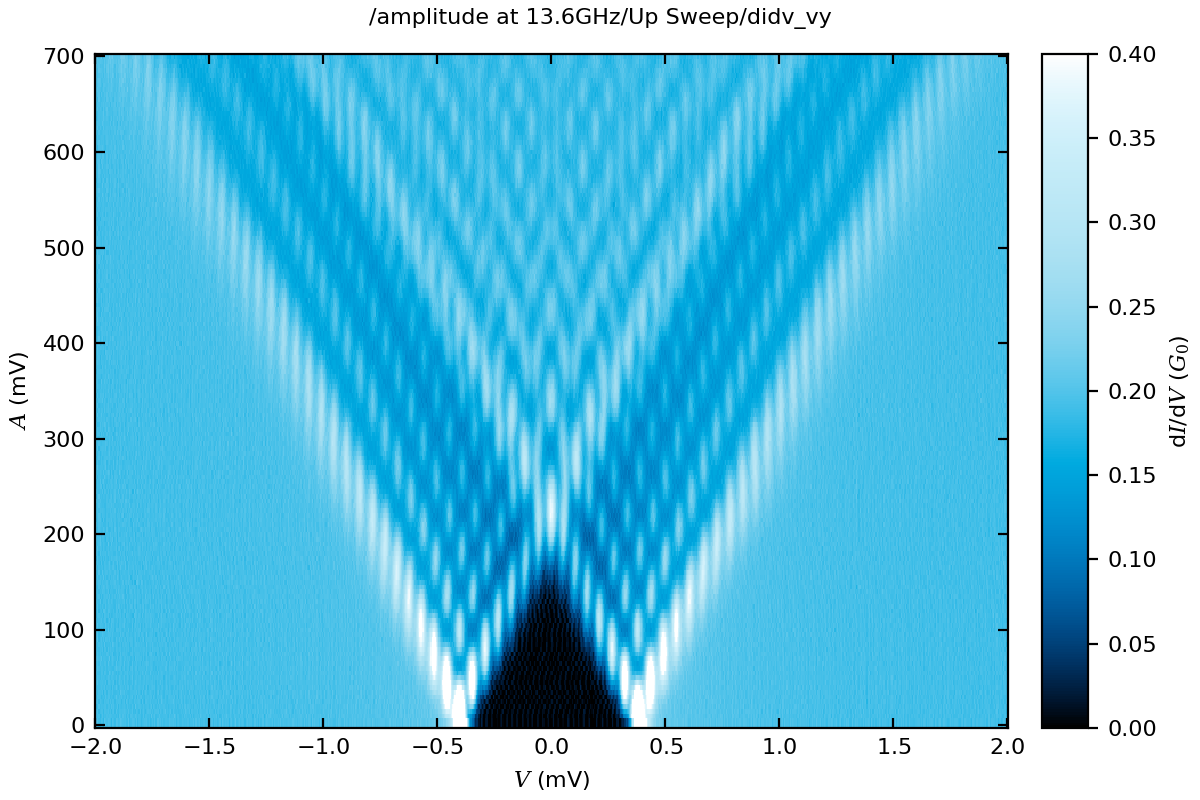

In [3]:
# plot and load exp data
from utilities.ivplot import IVPlot

importlib.reload(sys.modules["utilities.ivplot"])
logger = logging.getLogger()
logger.setLevel(level=logging.WARNING)

eva = IVPlot()
eva.title = f"amplitude at {nu_GHz:.1f}GHz"
eva.sub_folder = ""
eva.loadData()
eva.to_plot = eva.up_sweep
eva.title_of_plot = "Up Sweep"
eva.y_characters = [r"$A$", "V"]
eva.dvdi_norm = (1e3, "k")
eva.didv_c_lim = (0, 0.4)
eva.dvdi_c_lim = (0, 0.4e6)
if window_length > 2:
    eva.smoothing = True
    eva.window_length = window_length
else:
    eva.smoothing = False
eva.plot_T = False
eva.plot_dvdis = False
eva.plot_didvs = True
eva.plot_all()

In [4]:
x = eva.mapped["voltage_axis"] * 1e3
y = eva.mapped["y_axis"] * 1e3
z = eva.up_sweep["differential_conductance"]
y /= y.max()
y *= 4
y = y[::4]
z = z[::4, :]

In [5]:
# x = np.linspace(-6, 6, 2001)
# y = np.linspace(-5, 5, 71)
# X, Y = np.meshgrid(x, y, indexing="xy")

# z = (
#     1.0 * np.exp(-((X + 2.2) ** 2 + (Y + 0.4) ** 2) / 1.2**2)
#     + 0.8 * np.exp(-((X - 0.3) ** 2 + (Y - 0.8) ** 2) / 1.0**2)
#     + 0.9 * np.exp(-((X - 2.4) ** 2 + (Y + 1.0) ** 2) / 1.4**2)
# )